# JCX Payin Lookup V2 — Survival × Payin Table

**The v1 lookup with one new key: the loan's observed status at installment k.**

For matured loans grouped by `(CustType, Frequency_group3)`, each loan is classified at
k = 0..5 into `default@j` (j ≤ k) / `paid_off` / `alive`. The table stores, per cell:
- **share** — the state mix at k. *This is the survival table Michael asked for.*
- **expected_payin + q05/q95** — what loans in that state historically finished at.

Live projection at k = observed state mix × state-conditional payins. The band narrows
with k exactly as fast as history says it should — no simulation. One-sentence
explanation: *"loans that looked like yours at this point historically finished here."*

Design rationale + decisions: `skills/0611_survival_payin_lookup_v1.md`.
Source: same v14 extract (`#t17_combined`) used by training — no new SQL.

In [1]:
# Imports + paths (mirrors jcx_2026_projection_V5.ipynb)
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')

from util.db import create_db_engine
from util.sql_loader import read_sql_file
from util.sql_runner import execute_sql_and_read_temp_table
from util.plot_style import apply_plot_style, PRIMARY_COLOR, ACCENT_COLOR, PLOT_PALETTE
from util.payin_lookup import assign_frequency_group3
from util.payin_survival_lookup import (
    build_loan_summary,
    build_survival_payin_table,
    apply_survival_lookup,
    score_cohorts,
    status_at_k,
)

AS_OF_DATE = pd.Timestamp.today().normalize()
MATURITY_LAG_DAYS = 200      # loans older than this are 'matured' (final payin settled)
K_MAX = 5                    # the team's installment horizon
MIN_N = 50

project_root = Path.cwd().resolve().parent
engine = create_db_engine(project_root / '.env')
raw_df = execute_sql_and_read_temp_table(
    engine, read_sql_file(project_root / 'sql_scripts' / 'jcx_raw_harvey_v14.sql'), '#t17_combined')

raw_df['Frequency_group3'] = assign_frequency_group3(raw_df['Frequency'])
raw_df['CustType'] = raw_df['CustType'].astype(str).str.strip().str.upper()
print('raw rows:', len(raw_df), '| loans:', raw_df['LoanID'].nunique())

raw rows: 1046090 | loans: 206362


## 1. Loan summary + maturity split
`n_settled` counts installments with due date ≤ as-of (live, no settlement lag — team decision 2026-06-11).

In [2]:
summary = build_loan_summary(raw_df, as_of_date=AS_OF_DATE)
summary['OriginationDate'] = pd.to_datetime(summary['OriginationDate'], errors='coerce')

MATURITY_CUTOFF = AS_OF_DATE - pd.Timedelta(days=MATURITY_LAG_DAYS)
matured = summary[summary['OriginationDate'] <= MATURITY_CUTOFF].copy()
live = summary[summary['OriginationDate'] > MATURITY_CUTOFF].copy()

print(f'matured (train): {len(matured):,} loans (orig <= {MATURITY_CUTOFF.date()})')
print(f'live (project) : {len(live):,} loans')
print('\nmatured final payin ($-weighted):',
      round(float((matured['final_payin'] * matured['OriginatedAmount']).sum() / matured['OriginatedAmount'].sum()), 4))
summary.head()

matured (train): 178,202 loans (orig <= 2025-11-23)
live (project) : 28,110 loans

matured final payin ($-weighted): 1.6298


,LoanID,OriginatedAmount,OriginationDate,TotalRealizedPayment,AppYear,AppWeek,TotalInstallsNumber,CustType,Frequency_group3,earliest_default_inst,payoff_inst,n_settled,final_payin
0,I1529359-0,1500.0,2023-01-02,2109.68,2023,1,1,RETURN,M,NaN,1.0,1,1.406453
1,I1529362-0,600.0,2023-01-03,763.57,2023,1,2,RETURN,W,NaN,2.0,2,1.272617
2,I1529363-0,300.0,2023-01-03,358.50,2023,1,1,RETURN,B,NaN,1.0,1,1.195000
3,I1529364-0,500.0,2023-01-03,700.00,2023,1,1,RETURN,M,NaN,1.0,1,1.400000
4,I1529365-0,1500.0,2023-01-01,2461.00,2023,1,5,RETURN,B,5.0,NaN,5,1.640667


## 2. Build the survival × payin table

In [3]:
table = build_survival_payin_table(matured, ks=range(0, K_MAX + 1), min_n=MIN_N)
print('table cells:', len(table))

# Survival table (Michael's ask): state mix by k, per segment.
for (ct, fq), seg in table.groupby(['CustType', 'Frequency_group3']):
    mix = seg.pivot_table(index='status', columns='k', values='share', aggfunc='first').fillna(0)
    print(f'\n=== State mix — {ct} / {fq} ===')
    print((mix * 100).round(1))

table cells: 177

=== State mix — NEW / B ===
k              0     1     2     3     4     5
status                                        
alive      100.0  74.7  57.0  45.9  37.8  29.9
default@1    0.0  18.8  18.8  18.8  18.8  18.8
default@2    0.0   0.0  14.7  14.7  14.7  14.7
default@3    0.0   0.0   0.0   9.0   9.0   9.0
default@4    0.0   0.0   0.0   0.0   6.5   6.5
default@5    0.0   0.0   0.0   0.0   0.0   6.4
paid_off     0.0   6.5   9.5  11.6  13.1  14.6

=== State mix — NEW / M ===
k              0     1     2     3     4     5
status                                        
alive      100.0  72.5  51.8  38.9  30.4  23.8
default@1    0.0  16.5  16.5  16.5  16.5  16.5
default@2    0.0   0.0  16.6  16.6  16.6  16.6
default@3    0.0   0.0   0.0  10.3  10.3  10.3
default@4    0.0   0.0   0.0   0.0   6.7   6.7
default@5    0.0   0.0   0.0   0.0   0.0   5.2
paid_off     0.0  11.0  15.1  17.6  19.4  20.9

=== State mix — NEW / UNKNOWN ===
k              0     1     2     3     4    

## 3. The headline: band width by k for survivors
If this drops sharply by k=3–5, the team's 5-installment confidence target is met by the data itself.

Survivor (alive) cells — conditional final payin by k:
CustType Frequency_group3  k  n_loans  share  expected_payin   q05   q95  band_width
     NEW                B  0    57859  1.000           1.515 0.000 4.090       4.090
     NEW                B  1    43221  0.747           1.892 0.300 4.146       3.846
     NEW                B  2    32973  0.570           2.279 0.600 4.169       3.569
     NEW                B  3    26580  0.459           2.585 0.900 4.176       3.276
     NEW                B  4    21899  0.378           2.857 1.200 4.181       2.981
     NEW                B  5    17328  0.299           3.165 1.600 4.225       2.625
     NEW                M  0     8722  1.000           1.827 0.000 5.650       5.650
     NEW                M  1     6326  0.725           2.299 0.300 5.875       5.575
     NEW                M  2     4520  0.518           2.929 0.800 6.043       5.243
     NEW                M  3     3394  0.389           3.484 1.300 6.076       4.776
     NEW  

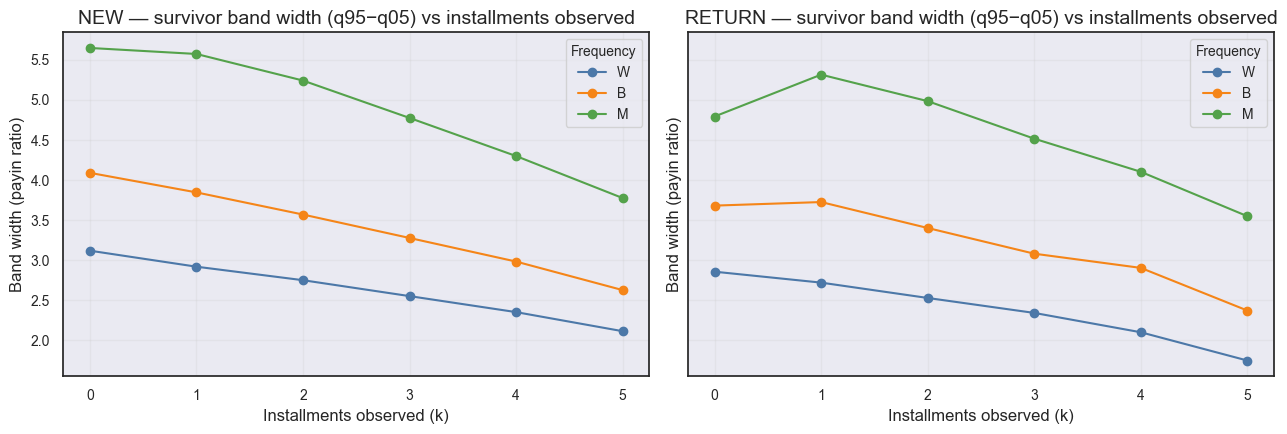

In [4]:
alive = table[table['status'] == 'alive'].copy()
print('Survivor (alive) cells — conditional final payin by k:')
print(alive[['CustType', 'Frequency_group3', 'k', 'n_loans', 'share',
             'expected_payin', 'q05', 'q95', 'band_width']]
      .sort_values(['CustType', 'Frequency_group3', 'k']).round(3).to_string(index=False))

apply_plot_style(style='white', axes_grid=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, ct in zip(axes, ['NEW', 'RETURN']):
    for i, fq in enumerate(['W', 'B', 'M']):
        sub = alive[(alive['CustType'] == ct) & (alive['Frequency_group3'] == fq)].sort_values('k')
        if sub.empty:
            continue
        ax.plot(sub['k'], sub['band_width'], 'o-', color=PLOT_PALETTE[i], label=f'{fq}')
    ax.set_title(f'{ct} — survivor band width (q95−q05) vs installments observed')
    ax.set_xlabel('Installments observed (k)')
    ax.set_ylabel('Band width (payin ratio)')
    ax.grid(alpha=0.25)
    ax.legend(title='Frequency')
plt.tight_layout()
plt.show()

## 4. Out-of-time backtest
Older matured cohorts build the table; newer matured cohorts (status frozen at k) are scored
against their known finals. Coverage target ≈ 90% for the q05–q95 band.

In [5]:
# DIAGNOSTIC: is the wide survivor band term-mix or real uncertainty?
# Split alive@5 by schedule length. If payin spread WITHIN a term bucket is small while
# means differ a lot ACROSS buckets, the band width is product mix (known at day zero),
# not behavioral uncertainty -> normalize by scheduled total (completion ratio).
m5 = matured.copy()
st5 = status_at_k(m5, 5)
alive5 = m5[st5 == 'alive'].copy()
alive5['term_bucket'] = pd.cut(
    pd.to_numeric(alive5['TotalInstallsNumber'], errors='coerce'),
    bins=[0, 7, 10, 14, 20, 99], labels=['<=7', '8-10', '11-14', '15-20', '21+'])

print('alive@5 final payin by (Frequency, term bucket) — NEW only:')
g = (alive5[alive5['CustType'] == 'NEW']
     .groupby(['Frequency_group3', 'term_bucket'], observed=True)['final_payin']
     .agg(n='size', mean='mean',
          q05=lambda s: s.quantile(0.05), q95=lambda s: s.quantile(0.95)))
g['within_width'] = g['q95'] - g['q05']
print(g.round(3).to_string())
print('\nRead: if within_width per bucket is much smaller than the pooled band (e.g. 2.6),')
print('term mix is the culprit -> switch the lookup target to completion = realized / scheduled_total_due.')


alive@5 final payin by (Frequency, term bucket) — NEW only:
                                 n   mean    q05    q95  within_width
Frequency_group3 term_bucket                                         
B                <=7          4328  2.140  1.380  3.035         1.655
                 8-10         4593  2.864  1.940  3.704         1.764
                 11-14        3677  3.546  2.541  4.354         1.813
                 15-20        4710  4.014  3.076  4.300         1.224
                 21+            20  3.529  3.320  3.811         0.492
M                <=7           565  3.045  2.215  4.185         1.970
                 8-10          639  4.112  3.098  5.002         1.904
                 11-14         440  5.129  3.675  5.806         2.131
                 15-20         430  5.663  3.858  6.294         2.436
UNKNOWN          <=7             1  1.970  1.970  1.970         0.000
W                <=7          1072  1.670  1.100  2.523         1.423
                 8-10         

In [6]:
cut = matured['OriginationDate'].quantile(0.7)
bt_train = matured[matured['OriginationDate'] <= cut]
bt_test = matured[matured['OriginationDate'] > cut].copy()
bt_table = build_survival_payin_table(bt_train, ks=range(0, K_MAX + 1), min_n=MIN_N)

rows = []
for k in range(0, K_MAX + 1):
    t = bt_test.copy()
    t['n_settled'] = k                      # freeze every test loan at k observed installments
    actual_final = t['final_payin'].copy()
    t['final_payin'] = 0.0                  # hide the answer from the floor logic
    sc = apply_survival_lookup(t, bt_table)
    err = sc['expected_payin'] - actual_final
    rows.append({
        'k': k,
        'loans': len(sc),
        'mae': float(err.abs().mean()),
        'bias': float(err.mean()),
        'coverage_q05_q95': float(((actual_final >= sc['q05']) & (actual_final <= sc['q95'])).mean()),
        'mean_band_width': float((sc['q95'] - sc['q05']).mean()),
    })
backtest = pd.DataFrame(rows)
print('Out-of-time backtest by k (loan-level):')
print(backtest.round(4).to_string(index=False))

Out-of-time backtest by k (loan-level):
 k  loans    mae   bias  coverage_q05_q95  mean_band_width
 0  53313 0.9733 0.1330            0.9324           3.9733
 1  53313 0.7369 0.0905            0.9324           2.7175
 2  53313 0.6056 0.0935            0.9227           2.2070
 3  53313 0.5260 0.0884            0.9195           1.9389
 4  53313 0.4773 0.0894            0.9172           1.8083
 5  53313 0.4498 0.1023            0.9143           1.7063


In [7]:
# Cohort-grain backtest — the Michael table.
# Same out-of-time split; now measure how far the COHORT-level projection was from the
# cohort's realized final, by k. Diversification makes these far tighter than loan-level.
rows = []
for k in range(0, K_MAX + 1):
    t = bt_test.copy()
    t['n_settled'] = k
    actual_final = t['final_payin'].copy()
    t['final_payin'] = 0.0
    sc = apply_survival_lookup(t, bt_table)
    sc['actual_final'] = actual_final.values
    coh = sc.groupby(['CustType', 'Frequency_group3', 'AppYear', 'AppWeek'])
    for key, g in coh:
        if len(g) < 30:
            continue
        w = g['OriginatedAmount'].clip(lower=0)
        proj = float((g['expected_payin'] * w).sum() / w.sum())
        act = float((g['actual_final'] * w).sum() / w.sum())
        rows.append({'k': k, 'CustType': key[0], 'Frequency_group3': key[1],
                     'cohort_err': proj - act})
cb = pd.DataFrame(rows)
cohort_backtest = (
    cb.groupby('k')['cohort_err']
    .agg(cohorts='size',
         mae=lambda s: s.abs().mean(),
         bias='mean',
         p05='min' if False else (lambda s: s.quantile(0.05)),
         p95=lambda s: s.quantile(0.95))
    .reset_index()
)
print('COHORT-grain backtest (n>=30 loans per cohort, $-weighted):')
print(cohort_backtest.round(4).to_string(index=False))
print('\nBy frequency (NEW only), MAE per k:')
print(cb[cb['CustType'] == 'NEW'].groupby(['Frequency_group3', 'k'])['cohort_err']
      .apply(lambda s: s.abs().mean()).round(3).unstack('k').to_string())
cohort_backtest.to_csv(project_root / 'projection_data' / 'app' / 'survival_backtest_cohort.csv', index=False)
cb.to_csv(project_root / 'projection_data' / 'app' / 'survival_backtest_cohort_detail.csv', index=False)
print('\nSaved survival_backtest_cohort.csv for the app.')


COHORT-grain backtest (n>=30 loans per cohort, $-weighted):
 k  cohorts    mae   bias     p05    p95
 0      285 0.1791 0.1345 -0.1667 0.4106
 1      285 0.1430 0.1044 -0.1313 0.3655
 2      285 0.1282 0.1012 -0.0918 0.3132
 3      285 0.1041 0.0815 -0.0640 0.2420
 4      285 0.0942 0.0759 -0.0588 0.2124
 5      285 0.0969 0.0841 -0.0473 0.2150

By frequency (NEW only), MAE per k:
k                     0      1      2      3      4      5
Frequency_group3                                          
B                 0.221  0.158  0.139  0.110  0.098  0.107
M                 0.227  0.212  0.189  0.138  0.106  0.110
W                 0.207  0.163  0.146  0.122  0.106  0.107

Saved survival_backtest_cohort.csv for the app.


## 5. Live cohorts — projection + band at today's observed status

In [8]:
scored_live = apply_survival_lookup(live, table)
scored_live['AppYear'] = pd.to_numeric(scored_live['AppYear'], errors='coerce').astype('Int64')
scored_live['AppWeek'] = pd.to_numeric(scored_live['AppWeek'], errors='coerce').astype('Int64')

cohorts = score_cohorts(scored_live, ['CustType', 'Frequency_group3', 'AppYear', 'AppWeek'])
cohorts['week_label'] = (
    cohorts['AppYear'].astype(str) + '-W' + cohorts['AppWeek'].astype(str).str.zfill(2)
)
cohorts = cohorts.sort_values(['CustType', 'Frequency_group3', 'AppYear', 'AppWeek'])

print('Live cohort projections (last 10 weeks shown per segment head):')
cohorts.tail(20).round(3)

Live cohort projections (last 10 weeks shown per segment head):


,CustType,Frequency_group3,AppYear,AppWeek,n_loans,orig_total,realized_payin,projected_payin,band_lo,band_hi,avg_k,pct_alive,pct_default,pct_paid_off,band_width,week_label
167,RETURN,W,2026,5,73,75650.0,1.673,1.823,0.995,2.196,3.432,0.438,0.151,0.411,1.200,2026-W05
168,RETURN,W,2026,6,62,58600.0,1.491,1.668,0.958,2.070,3.196,0.419,0.161,0.419,1.112,2026-W06
169,RETURN,W,2026,7,61,54250.0,1.461,1.618,0.962,1.980,3.155,0.361,0.180,0.459,1.018,2026-W07
170,RETURN,W,2026,8,46,41850.0,1.522,1.648,1.036,1.931,3.014,0.283,0.109,0.609,0.894,2026-W08
171,RETURN,W,2026,9,60,56150.0,1.415,1.553,0.932,1.969,3.203,0.383,0.150,0.467,1.037,2026-W09
172,RETURN,W,2026,10,56,50550.0,1.493,1.617,0.938,2.098,3.362,0.393,0.214,0.393,1.160,2026-W10
173,RETURN,W,2026,11,56,54950.0,1.392,1.601,0.873,2.156,3.428,0.375,0.268,0.357,1.282,2026-W11
174,RETURN,W,2026,12,55,48650.0,1.438,1.697,0.960,2.225,3.529,0.509,0.164,0.327,1.265,2026-W12
175,RETURN,W,2026,13,51,44300.0,1.320,1.623,0.936,2.196,3.460,0.392,0.216,0.392,1.260,2026-W13
176,RETURN,W,2026,14,83,74050.0,1.164,1.531,0.933,2.016,3.157,0.361,0.157,0.482,1.083,2026-W14


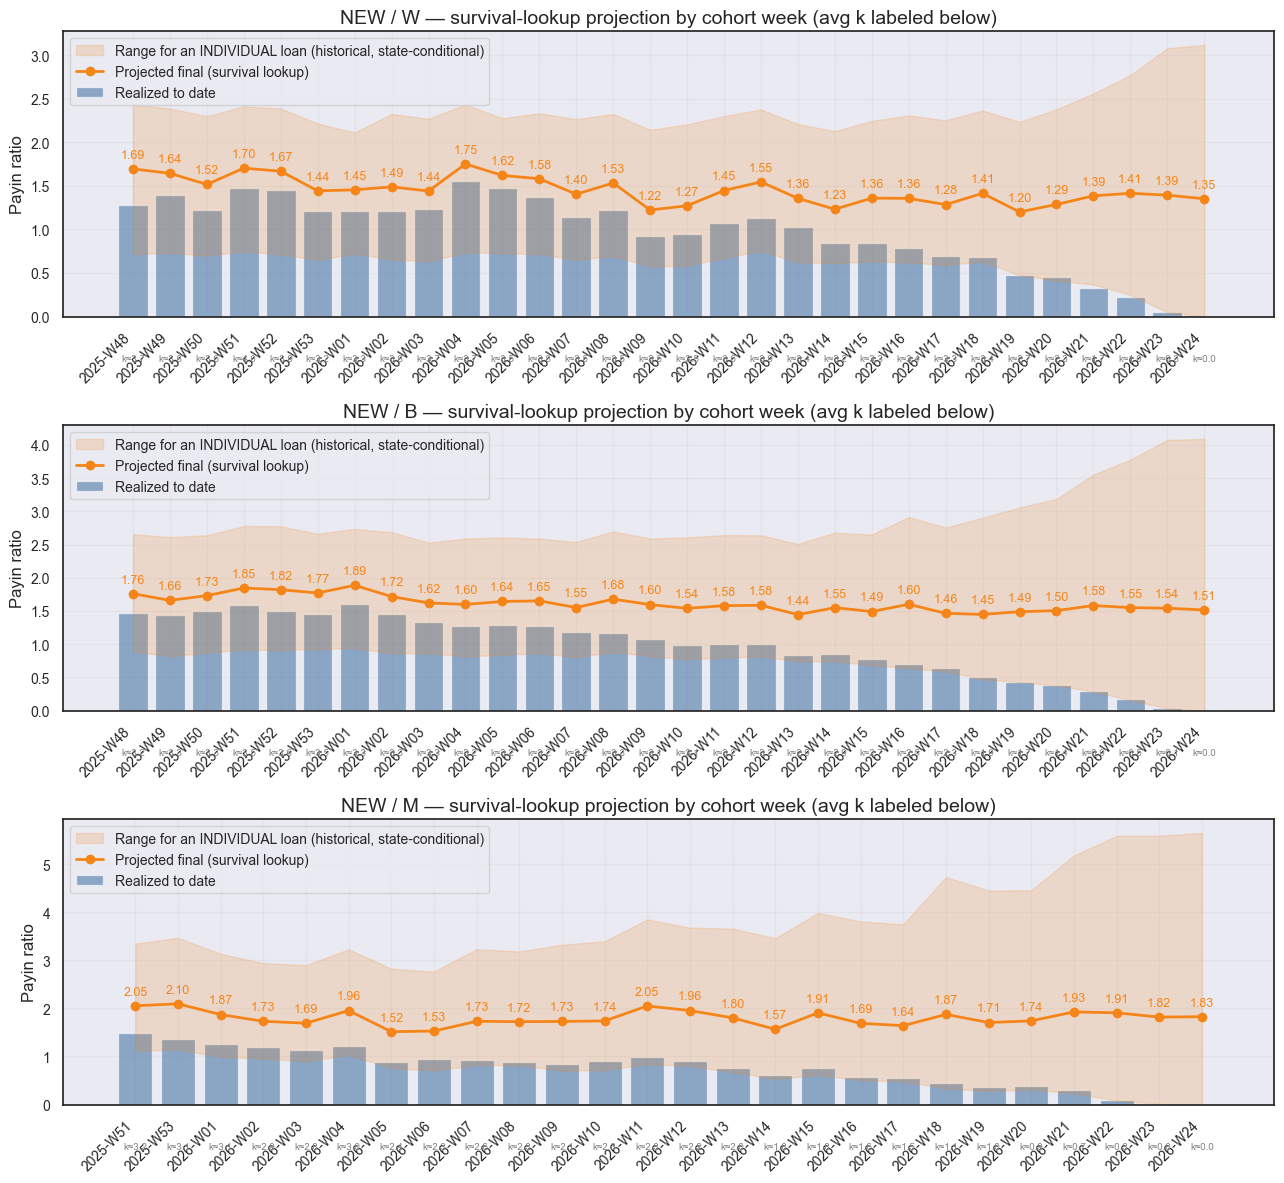

In [9]:
# Faceted cohort chart: one panel per frequency (Michael's blob fix), NEW only to start.
apply_plot_style(style='white', axes_grid=False)
freqs = ['W', 'B', 'M']
fig, axes = plt.subplots(len(freqs), 1, figsize=(13, 4 * len(freqs)), sharex=False)
for ax, fq in zip(np.atleast_1d(axes), freqs):
    sub = cohorts[(cohorts['CustType'] == 'NEW') & (cohorts['Frequency_group3'] == fq)].copy()
    sub = sub[sub['n_loans'] >= 20]
    if sub.empty:
        ax.set_title(f'NEW / {fq} — no cohorts with n>=20')
        continue
    x = np.arange(len(sub))
    ax.bar(x, sub['realized_payin'], color=PRIMARY_COLOR, alpha=0.6, label='Realized to date')
    ax.fill_between(x, sub['band_lo'], sub['band_hi'], color=ACCENT_COLOR, alpha=0.18,
                    label='Range for an INDIVIDUAL loan (historical, state-conditional)')
    ax.plot(x, sub['projected_payin'], 'o-', color=ACCENT_COLOR, linewidth=2,
            label='Projected final (survival lookup)')
    for xi, yp in zip(x, sub['projected_payin']):
        ax.annotate(f'{yp:.2f}', (xi, yp), textcoords='offset points', xytext=(0, 8),
                    ha='center', color=ACCENT_COLOR, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['week_label'], rotation=45, ha='right')
    ax.set_ylabel('Payin ratio')
    ax.set_title(f'NEW / {fq} — survival-lookup projection by cohort week (avg k labeled below)')
    for xi, ak in zip(x, sub['avg_k']):
        ax.annotate(f'k≈{ak:.1f}', (xi, 0), textcoords='offset points', xytext=(0, -32),
                    ha='center', fontsize=7, color='gray')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
# Cumulative collections by installment — Michael's tracking curves.
# Stored as $ SUMS (not ratios) so the app can blend segments bottom-up.
#   hist: per (segment, InstallmentNumber): step collected $ + segment orig total (matured loans).
#   live: same per cohort week, settled installments only (due date <= as-of).
K_DISPLAY = 20
norm = raw_df[pd.to_numeric(raw_df['iPaymentMode'], errors='coerce') == 144].copy()
norm['InstallmentNumber'] = pd.to_numeric(norm['InstallmentNumber'], errors='coerce')
norm = norm[norm['InstallmentNumber'].between(1, K_DISPLAY)]
norm['InstallRealizedPayment'] = pd.to_numeric(norm['InstallRealizedPayment'], errors='coerce').fillna(0.0)
norm['OriginationDate'] = pd.to_datetime(norm['OriginationDate'], errors='coerce')
norm['InstallmentDueDate'] = pd.to_datetime(norm['InstallmentDueDate'], errors='coerce')
SEG = ['CustType', 'Frequency_group3']

def _orig_total(df):
    per_loan = df.groupby('LoanID')['OriginatedAmount'].first()
    return float(pd.to_numeric(per_loan, errors='coerce').fillna(0).sum())

hist_rows, live_rows = [], []
hist_norm = norm[norm['OriginationDate'] <= MATURITY_CUTOFF]
for seg_key, g in hist_norm.groupby(SEG):
    orig_total = _orig_total(g)
    steps = g.groupby('InstallmentNumber')['InstallRealizedPayment'].sum()
    for j in range(1, K_DISPLAY + 1):
        hist_rows.append({**dict(zip(SEG, seg_key)), 'InstallmentNumber': j,
                          'step_amount': float(steps.get(j, 0.0)), 'orig_total': orig_total})
live_norm = norm[(norm['OriginationDate'] > MATURITY_CUTOFF)
                 & norm['InstallmentDueDate'].le(AS_OF_DATE)]
for key, g in live_norm.groupby([*SEG, 'AppYear', 'AppWeek']):
    orig_total = _orig_total(g)
    steps = g.groupby('InstallmentNumber')['InstallRealizedPayment'].sum()
    for j in sorted(g['InstallmentNumber'].dropna().astype(int).unique()):
        live_rows.append({**dict(zip([*SEG, 'AppYear', 'AppWeek'], key)), 'InstallmentNumber': int(j),
                          'step_amount': float(steps.get(j, 0.0)), 'orig_total': orig_total})

install_curve_hist = pd.DataFrame(hist_rows)
install_curve_live = pd.DataFrame(live_rows)
APP_DIR = project_root / 'projection_data' / 'app'
APP_DIR.mkdir(parents=True, exist_ok=True)
install_curve_hist.to_csv(APP_DIR / 'install_curve_hist.csv', index=False)
install_curve_live.to_csv(APP_DIR / 'install_curve_live.csv', index=False)
print('install_curve_hist:', len(install_curve_hist), 'rows | install_curve_live:', len(install_curve_live), 'rows')


install_curve_hist: 140 rows | install_curve_live: 1745 rows


## 6. Export artifacts for the Streamlit app (tab 2: installment tracking)

In [11]:
APP_DATA_DIR = project_root / 'projection_data' / 'app'
APP_DATA_DIR.mkdir(parents=True, exist_ok=True)

table.to_csv(APP_DATA_DIR / 'survival_payin_table.csv', index=False)
cohorts.to_csv(APP_DATA_DIR / 'live_cohorts_v2.csv', index=False)
backtest.to_csv(APP_DATA_DIR / 'survival_backtest.csv', index=False)

import json as _json
(APP_DATA_DIR / 'meta_v2.json').write_text(_json.dumps({
    'as_of_date': str(AS_OF_DATE.date()),
    'maturity_cutoff': str(MATURITY_CUTOFF.date()),
    'k_max': K_MAX,
    'min_n': MIN_N,
    'matured_loans': int(len(matured)),
    'live_loans': int(len(live)),
}, indent=2))

print('Exported to', APP_DATA_DIR)
print('  survival_payin_table.csv:', len(table), 'rows')
print('  live_cohorts_v2.csv     :', len(cohorts), 'rows')
print('  survival_backtest.csv   :', len(backtest), 'rows')

Exported to /Users/starsrain/2025_concord/yieldCurve_augmenting/projection_data/app
  survival_payin_table.csv: 177 rows
  live_cohorts_v2.csv     : 187 rows
  survival_backtest.csv   : 6 rows


## Notes / open items
- Status uses `isInstallDefault` / `LoanPaidOffThisInstall` from the v14 extract — same
  flags as `util/xpd_features.py`. `n_settled` = installments with due date ≤ as-of (live,
  no settlement lag — team decision).
- If k=1 survivor cells are still wide, the next refinement is splitting `alive` by
  *clean pull vs bounced-then-recovered* using the SP payment attempt data.
- The 3-stage model remains the scenario engine (DM-band tightening); this table is the
  tracking + confidence engine.
- Backtest coverage materially below ~0.90 at low k → widen quantiles or add a segment key.